In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from my_functions import df_to_table, move_column, add_custom_id_column, visualize_count_plot, visualize_and_label_count_plot

pd.set_option('display.max_columns', None)

# Combine datasets

In [2]:
gaming_data = pd.read_csv('../data/gaming_GAD_CLEAN.csv')
nhis_data = pd.read_csv('../data/nhis_GAD_CLEAN.csv')

In [3]:
# Check what columns are different between the two dataframes

set(gaming_data.columns) ^ set(nhis_data.columns)

{'Degree',
 'Gender',
 'game',
 'hours',
 'participant_id_OLD',
 'platform',
 'playstyle',
 'reason',
 'region_id'}

In [4]:
df = pd.concat([gaming_data, nhis_data], ignore_index=True, sort=False)
df.head()

# Reference: https://pandas.pydata.org/docs/user_guide/merging.html

,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
0,1,2015,0,0,0,0,1,0,0,1,1,1,25,8,1,USA,Skyrim,Bachelor (or equivalent),Console,15.0,having fun,Singleplayer,Male,NaN,NaN
1,2,2015,1,2,2,2,0,1,0,8,2,1,41,8,1,USA,Other,Bachelor (or equivalent),PC,8.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN
2,3,2015,0,2,2,0,0,3,1,8,2,2,32,8,1,DEU,Other,Bachelor (or equivalent),PC,0.0,having fun,Singleplayer,Female,NaN,NaN
3,4,2015,0,0,0,0,0,0,0,0,1,1,28,8,1,USA,Other,Bachelor (or equivalent),PC,20.0,improving,Multiplayer - online - with online acquaintanc...,Male,NaN,NaN
4,5,2015,2,1,2,2,2,3,2,14,3,1,19,12,1,KOR,Other,High school diploma (or equivalent),Console,20.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


In [5]:
# This remains from an unknown issue before where both datasets had a participant with this id

# filtered_data = df.loc[df['participant_id'] == 43]
# filtered_data

In [6]:
# Confirming that the data fix was successful

# filtered_data = df.loc[df['GAD_total'] > 21]
# filtered_data

# GAD_total needs to be recalculated after data correction

In [7]:
# Confirm that no number is >21
df['GAD_total'].unique()

array([ 1,  8,  0, 14, 12, 10, 19,  3,  2,  4, 15,  5,  6,  7, 13, 11,  9,
       18, 16, 21, 17, 20])

## Add a surrogate key for partcipant_id in this new dataframe
This will help avoid any duplicate ids in the analysis.

### Rename original participant_id column

In [8]:
df = df.rename(columns={'participant_id' : 'OLD_participant_id'})
df.tail()

,OLD_participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
44451,46022,2019,0,0,0,0,0,0,0,0,1,2,68,7,2,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,H046022
44452,46232,2019,0,0,0,0,0,0,0,0,1,1,47,5,2,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,H046232
44453,43765,2019,0,0,0,0,0,1,0,1,1,1,68,5,2,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,H043765
44454,17695,2019,0,0,1,0,0,0,0,1,1,2,31,7,2,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,H017695
44455,26306,2019,0,0,0,0,0,0,0,0,1,2,54,5,2,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,H026306


### Make and fill new participant_id column

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44456 entries, 0 to 44455
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OLD_participant_id  44456 non-null  int64  
 1   year                44456 non-null  int64  
 2   GAD1                44456 non-null  int64  
 3   GAD2                44456 non-null  int64  
 4   GAD3                44456 non-null  int64  
 5   GAD4                44456 non-null  int64  
 6   GAD5                44456 non-null  int64  
 7   GAD6                44456 non-null  int64  
 8   GAD7                44456 non-null  int64  
 9   GAD_total           44456 non-null  int64  
 10  GAD_cat             44456 non-null  int64  
 11  sex_id              44456 non-null  int64  
 12  age                 44456 non-null  int64  
 13  education_id        44456 non-null  int64  
 14  survey_id           44456 non-null  int64  
 15  residence           44456 non-null  str    
 16  game           

In [10]:
add_custom_id_column(df, 'participant_id', 10000)

df.head()

,participant_id,OLD_participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
0,10000,1,2015,0,0,0,0,1,0,0,1,1,1,25,8,1,USA,Skyrim,Bachelor (or equivalent),Console,15.0,having fun,Singleplayer,Male,NaN,NaN
1,10001,2,2015,1,2,2,2,0,1,0,8,2,1,41,8,1,USA,Other,Bachelor (or equivalent),PC,8.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN
2,10002,3,2015,0,2,2,0,0,3,1,8,2,2,32,8,1,DEU,Other,Bachelor (or equivalent),PC,0.0,having fun,Singleplayer,Female,NaN,NaN
3,10003,4,2015,0,0,0,0,0,0,0,0,1,1,28,8,1,USA,Other,Bachelor (or equivalent),PC,20.0,improving,Multiplayer - online - with online acquaintanc...,Male,NaN,NaN
4,10004,5,2015,2,1,2,2,2,3,2,14,3,1,19,12,1,KOR,Other,High school diploma (or equivalent),Console,20.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


# Build Relational Tables

## Create unique dataframes

In [11]:
# ================
# Fact tables
# ================


participant_df = df[['participant_id', 'survey_id', 'sex_id', 'education_id', 'residence', 'age', 'region_id']].drop_duplicates()

GAD_response_df = df[['participant_id', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'GAD_total', 'GAD_cat']]

gaming_response_df = df[['participant_id', 'survey_id', 'game', 'platform', 'hours', 'reason', 'playstyle']].drop_duplicates()

# ================
# Lookup tables
# ================

survey_df = pd.DataFrame({
    'survey_id': [1, 2],
    'survey_name': ['Gamers', 'NHIS'],
    'year': [2015, 2019],
    'population':['global', 'America']
})


GAD_categories = {
    1:'None/Minimal', 
    2:'Mild', 
    3:'Moderate', 
    4:'Severe', 
    8:'Not Ascertained'
}

GAD_cat_df = (
    pd.Series(GAD_categories, name='cat_name')
        .rename_axis('GAD_cat')
        .reset_index()
)

sex_lookup = {
    1: 'Male', 
    2:'Female',
    3: 'Other', 
    7:'Refused', 
    8:'Not Ascertained',
    9:"Don't Know"
}
sex_df = (
    pd.Series(sex_lookup, name='sex_name')
        .rename_axis('sex_id')
        .reset_index()
)


degree_lookup = {
    0:'Never attended/kindergarten only', 
    1: 'Grade 1-11',
    2: '12th grade, no diploma',
    3: 'GED or equivalent',
    4: 'High School Graduate',
    5: 'Some college, no degree',
    6: 'Associate degree: occupational, technical, or vocational program',
    7: 'Associate degree: academic program',
    8: "Bachelor's degree (Example: BA, AB, BS, BBA)",
    9: "Master's degree or equivalent (Example: MA, MS, MEng, MEd, MBA)",
    10: "Professional School degree (Example: MD, DDS, DVM, JD)",
    11: "Doctoral degree (Example: PhD, EdD)",
    12: "High school diploma (or equivalent)",
    13: "Ph.D., Psy. D., MD (or equivalent)",
    97: "Refused",
    98: "Not Ascertained",
    99:"Don't Know"
}
education_df = (
    pd.Series(degree_lookup, name='level')
        .rename_axis('education_id')
        .reset_index()
)


region_lookup = {
    1: 'Northeast',
    2: 'Midwest',
    3: 'South', 
    4: 'West'
}
region_df = (
    pd.Series(region_lookup, name='name')
        .rename_axis('region_id')
        .reset_index()
)

# I conferred with ChatGPT to decide how to set up the lookup tables
# it recommended using dictionaries to set them up to make it easier to 
# read and maintain. I did this for the longer descriptions

## Add custom id columns to GAD_response_df and gaming_response_df
This will be a unique identifier and primary key

Reference: https://www.geeksforgeeks.org/python/create-a-pandas-column-using-for-loop/

In [12]:
add_custom_id_column(GAD_response_df, 'GAD_response_id', 1000)

GAD_response_df.head()

,GAD_response_id,participant_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1000,10000,0,0,0,0,1,0,0,1,1
1,1001,10001,1,2,2,2,0,1,0,8,2
2,1002,10002,0,2,2,0,0,3,1,8,2
3,1003,10003,0,0,0,0,0,0,0,0,1
4,1004,10004,2,1,2,2,2,3,2,14,3


In [13]:
add_custom_id_column(gaming_response_df, 'gaming_response_id', 2000)

gaming_response_df.head()

,gaming_response_id,participant_id,survey_id,game,platform,hours,reason,playstyle
0,2000,10000,1,Skyrim,Console,15.0,having fun,Singleplayer
1,2001,10001,1,Other,PC,8.0,having fun,Multiplayer - online - with strangers
2,2002,10002,1,Other,PC,0.0,having fun,Singleplayer
3,2003,10003,1,Other,PC,20.0,improving,Multiplayer - online - with online acquaintanc...
4,2004,10004,1,Other,Console,20.0,having fun,Multiplayer - online - with strangers


## Create database tables

In [14]:
conn = sqlite3.connect('../data/mentalhealth.db')

df_to_table(participant_df, 'participant', conn)
df_to_table(GAD_response_df, 'GAD_response', conn)
df_to_table(gaming_response_df, 'gaming_response', conn)
df_to_table(survey_df, 'survey', conn)
df_to_table(GAD_cat_df, 'GAD_category', conn)
df_to_table(sex_df, 'sex', conn)
df_to_table(education_df, 'education', conn)
df_to_table(region_df, 'region', conn)

# Exploratory Data Analysis

## QUERIES

### Create a temporary view

In [15]:
# conn.execute is better to use to modify data where
# pd.read_sql is best to pull query results

# I consulted with Chat GPT here for a way to reduce the 
# amount of repetitive SQL code I originally had.

conn.execute("""
    CREATE TEMP VIEW gad_eda_data AS
    SELECT
        p.participant_id,
        p.survey_id,
        p.sex_id,
        p.education_id,
        p.residence,
        p.age,
        p.region_id,
        r.GAD1,
        r.GAD2,
        r.GAD3,
        r.GAD4,
        r.GAD5,
        r.GAD6,
        r.GAD7,
        r.GAD_total,
        r.GAD_cat
    FROM participant p
    JOIN GAD_response r on r.participant_id = p.participant_id
    WHERE p.residence == 'USA'
        AND p.age BETWEEN 18 AND 22;
""")

In [16]:
all_data_scores_q = """
SELECT * FROM gad_eda_data
"""

all_data_scores_r = pd.read_sql(all_data_scores_q, conn)
all_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,10010,1,2,12,USA,21,NaN,3,3,3,3,1,3,3,19,4
1,10012,1,1,12,USA,18,NaN,0,0,0,0,0,0,0,0,1
2,10013,1,1,12,USA,19,NaN,0,0,1,0,0,1,1,3,1
3,10028,1,1,12,USA,19,NaN,1,0,2,1,0,0,0,4,1
4,10029,1,1,99,USA,18,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,54416,2,2,5,USA,20,2.0,1,0,0,0,0,1,0,2,1
4798,54423,2,1,5,USA,19,2.0,0,0,0,0,0,0,0,0,1
4799,54443,2,1,3,USA,22,4.0,2,0,0,0,1,3,0,6,2
4800,54449,2,2,1,USA,18,4.0,3,3,3,0,3,3,0,15,4


### Participant data and scores (USA) (usa_data_scores_r)

In [17]:
usa_data_scores_q = """
SELECT * FROM gad_eda_data
"""

usa_data_scores_r = pd.read_sql(usa_data_scores_q, conn)
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,10010,1,2,12,USA,21,NaN,3,3,3,3,1,3,3,19,4
1,10012,1,1,12,USA,18,NaN,0,0,0,0,0,0,0,0,1
2,10013,1,1,12,USA,19,NaN,0,0,1,0,0,1,1,3,1
3,10028,1,1,12,USA,19,NaN,1,0,2,1,0,0,0,4,1
4,10029,1,1,99,USA,18,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,54416,2,2,5,USA,20,2.0,1,0,0,0,0,1,0,2,1
4798,54423,2,1,5,USA,19,2.0,0,0,0,0,0,0,0,0,1
4799,54443,2,1,3,USA,22,4.0,2,0,0,0,1,3,0,6,2
4800,54449,2,2,1,USA,18,4.0,3,3,3,0,3,3,0,15,4


### NHIS data and scores (nhis_data_scores_r)

In [18]:
nhis_data_scores_q = """
SELECT * FROM gad_eda_data
WHERE survey_id = 2
"""

nhis_data_scores_r = pd.read_sql(nhis_data_scores_q, conn)
nhis_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,23341,2,1,4,USA,21,3.0,0,0,0,0,0,0,0,0,1
1,23360,2,2,4,USA,20,4.0,0,0,0,0,0,0,0,0,1
2,23420,2,1,1,USA,19,3.0,0,0,0,0,0,0,0,0,1
3,23496,2,2,4,USA,18,4.0,1,0,0,1,1,1,0,4,1
4,23520,2,1,5,USA,20,4.0,0,1,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,54416,2,2,5,USA,20,2.0,1,0,0,0,0,1,0,2,1
1406,54423,2,1,5,USA,19,2.0,0,0,0,0,0,0,0,0,1
1407,54443,2,1,3,USA,22,4.0,2,0,0,0,1,3,0,6,2
1408,54449,2,2,1,USA,18,4.0,3,3,3,0,3,3,0,15,4


### Gamer data and scores (USA) (usa_gamer_data_scores_r)

In [19]:
usa_gamer_data_scores_q = """
SELECT * FROM gad_eda_data
WHERE survey_id = 1
"""

usa_gamer_data_scores_r = pd.read_sql(usa_gamer_data_scores_q, conn)
usa_gamer_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,10010,1,2,12,USA,21,None,3,3,3,3,1,3,3,19,4
1,10012,1,1,12,USA,18,None,0,0,0,0,0,0,0,0,1
2,10013,1,1,12,USA,19,None,0,0,1,0,0,1,1,3,1
3,10028,1,1,12,USA,19,None,1,0,2,1,0,0,0,4,1
4,10029,1,1,99,USA,18,None,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3387,23304,1,1,8,USA,21,None,0,0,1,0,0,0,0,1,1
3388,23305,1,1,99,USA,18,None,2,1,3,0,3,1,1,11,3
3389,23311,1,1,12,USA,18,None,0,0,1,0,0,1,0,2,1
3390,23318,1,1,12,USA,21,None,0,1,1,1,0,2,1,6,2


In [20]:
#Global gamer data

# all_gamer_data_scores_q = """
# SELECT * FROM gad_eda_data
# WHERE survey_id = 1
# """

# all_gamer_data_scores_r = pd.read_sql(all_gamer_data_scores_q, conn)
# all_gamer_data_scores_r

### Scores by sex (sex_data_scores_r)

In [26]:
sex_data_scores_q = """
    SELECT
        g.sex_id,
        s.sex_name,
        AVG(g.GAD1),
        AVG(g.GAD2),
        AVG(g.GAD3),
        AVG(g.GAD4),
        AVG(g.GAD5),
        AVG(g.GAD6),
        AVG(g.GAD7),
        AVG(g.GAD_total),
        AVG(g.GAD_cat),
        count(g.sex_id) as total_participants
    FROM gad_eda_data g
    JOIN sex s on s.sex_id = g.sex_id
    GROUP BY g.sex_id;
"""

sex_data_scores_r = pd.read_sql(sex_data_scores_q, conn)
sex_data_scores_r

,sex_id,sex_name,AVG(g.GAD1),AVG(g.GAD2),AVG(g.GAD3),AVG(g.GAD4),AVG(g.GAD5),AVG(g.GAD6),AVG(g.GAD7),AVG(g.GAD_total),AVG(g.GAD_cat),total_participants
0,1,Male,0.801089,0.581172,0.844139,0.652749,0.500259,0.818465,0.506743,4.704616,1.608402,3856
1,2,Female,0.768162,0.660256,0.822650,0.608974,0.370726,0.747863,0.451923,4.430556,1.618590,936
2,3,Other,1.900000,1.000000,1.800000,1.700000,1.300000,1.300000,1.000000,10.000000,2.500000,10


## Visualizations

- box & whisker plot of scores (total and by survey)

### Heat map: Is there an observable and unexptected correlation in the data?

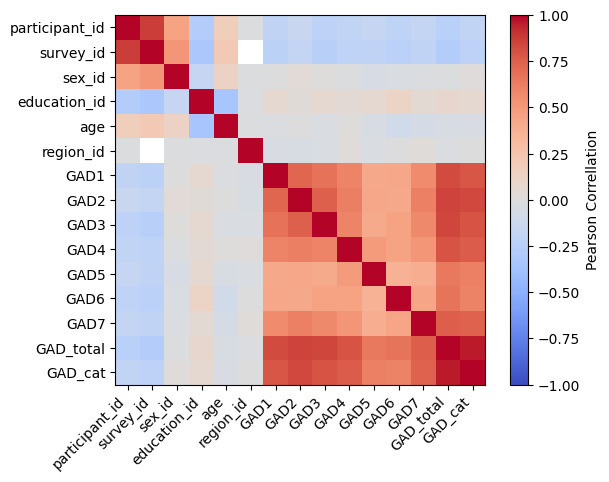

In [27]:
numeric_usa_df = usa_data_scores_r.select_dtypes(include=[np.number])
corr = numeric_usa_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, label='Pearson Correllation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

There do not appear to be any strong, unexpected correlations revealed by this heat map.

### Pie chart: What is the division of participants' identified sex?

In [28]:
category = 'sex_name'
values = 'total_participants'

sex_totals = sex_data_scores_r.groupby(category)[values].sum()
sex_totals

sex_name
Female     936
Male      3856
Other       10
Name: total_participants, dtype: int64

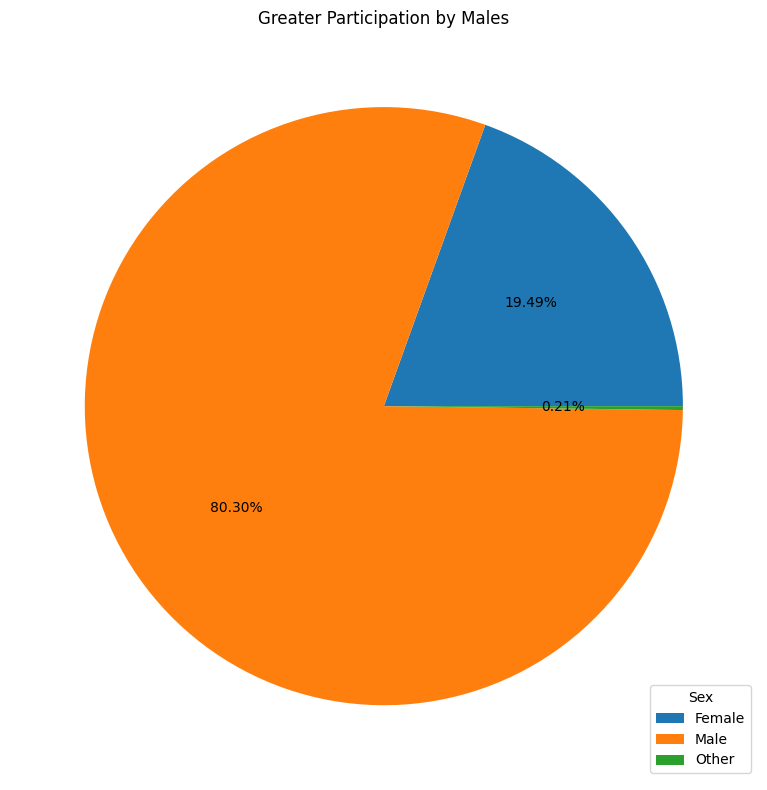

In [29]:
plt.figure(figsize=(8,8))
plt.pie(
    sex_totals,
    labels=None,
    autopct='%1.2f%%'
)

plt.title('Greater Participation by Males')

plt.legend(
    labels=sex_totals.index,
    loc='lower right',
    title='Sex'
)

plt.tight_layout()
plt.show()

### Bar chart: What is the average GAD score for each survey? (USA)

In [30]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,10010,1,2,12,USA,21,NaN,3,3,3,3,1,3,3,19,4
1,10012,1,1,12,USA,18,NaN,0,0,0,0,0,0,0,0,1
2,10013,1,1,12,USA,19,NaN,0,0,1,0,0,1,1,3,1
3,10028,1,1,12,USA,19,NaN,1,0,2,1,0,0,0,4,1
4,10029,1,1,99,USA,18,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,54416,2,2,5,USA,20,2.0,1,0,0,0,0,1,0,2,1
4798,54423,2,1,5,USA,19,2.0,0,0,0,0,0,0,0,0,1
4799,54443,2,1,3,USA,22,4.0,2,0,0,0,1,3,0,6,2
4800,54449,2,2,1,USA,18,4.0,3,3,3,0,3,3,0,15,4


In [31]:
avg_score = usa_data_scores_r.groupby('survey_id')['GAD_total'].mean()
avg_score

survey_id
1    5.528007
2    2.579433
Name: GAD_total, dtype: float64

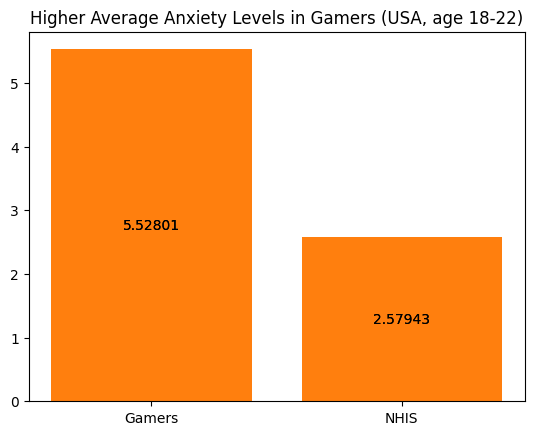

In [60]:
surveys = ('Gamers', 'NHIS')

fig, ax = plt.subplots()
bottom = np.zeros(2)

for survey in avg_score.items():
    p = ax.bar(surveys, avg_score, label=survey, bottom=bottom)
    ax.bar_label(p, label_type='center')

ax.set_title('Higher Average Anxiety Levels in Gamers (USA, age 18-22)')

plt.show()

# Reference: 
#   x-tick labels: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html

### Count plots of avg scores

#### How do the GAD score totals compare across all participants?

In [33]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,10010,1,2,12,USA,21,NaN,3,3,3,3,1,3,3,19,4
1,10012,1,1,12,USA,18,NaN,0,0,0,0,0,0,0,0,1
2,10013,1,1,12,USA,19,NaN,0,0,1,0,0,1,1,3,1
3,10028,1,1,12,USA,19,NaN,1,0,2,1,0,0,0,4,1
4,10029,1,1,99,USA,18,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,54416,2,2,5,USA,20,2.0,1,0,0,0,0,1,0,2,1
4798,54423,2,1,5,USA,19,2.0,0,0,0,0,0,0,0,0,1
4799,54443,2,1,3,USA,22,4.0,2,0,0,0,1,3,0,6,2
4800,54449,2,2,1,USA,18,4.0,3,3,3,0,3,3,0,15,4


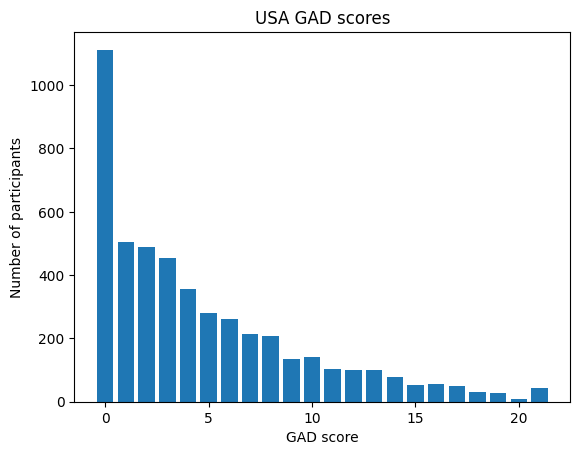

In [34]:
usa_score_count = usa_data_scores_r['GAD_total'].value_counts()

visualize_count_plot(usa_score_count, 'GAD score', 'Number of participants', 'USA GAD scores')

In [35]:
usa_score_count.head()

GAD_total
0    1112
1     506
2     488
3     455
4     356
Name: count, dtype: int64

In [36]:
# investigating  why any number is above total possible GAD score of 21
# usa_data_scores_r['GAD_total'].unique()

In [37]:
# filtered_scores = usa_data_scores_r.loc[usa_data_scores_r['GAD_total'] > 21]
# filtered_scores

# The highest number that SHOULD be possible in the GAD1-7 columns is 3.

#### How do the GAD score totals compare across USA gamer participants?

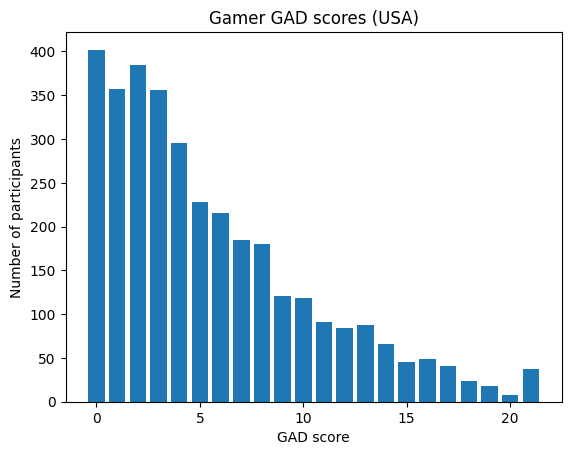

In [38]:
usa_gamer_data_scores = usa_gamer_data_scores_r['GAD_total'].value_counts()

visualize_count_plot(usa_gamer_data_scores, 'GAD score', 'Number of participants', 'Gamer GAD scores (USA)')

#### How do the GAD score totals compare across NHIS participants?

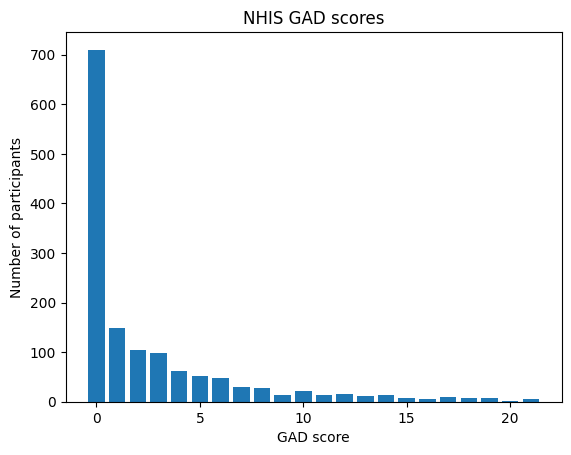

In [39]:
nhis_data_scores = nhis_data_scores_r['GAD_total'].value_counts()

visualize_count_plot(nhis_data_scores, 'GAD score', 'Number of participants', 'NHIS GAD scores')

#### How do the GAD score totals compare across age?

In [40]:
# usa_age_data_scores_r['age'].value_counts()

# Ages range from 18-99

In [41]:
#  The original exploration here can be found in preliminary_analysis/notebooks/eda.ipynb, including resources

# Commented out because this does not accomplish what I am wanting to visualize. This groups the average scores of average scores and it feels like that muddies the comparison further than a count plot would.

# bins = [18, 29, 39, 49, 59, 69, 79, 89, 99]
# labels = ['18-28', '29-38','39-48', '49-58', '59-68', '69-78', '79-88', '88+']

# usa_age_data_scores_r['age_binned'] = pd.cut(usa_age_data_scores_r['age'], bins=bins, labels=labels)

# usa_age_data_scores_r.head()


# usa_age_data_scores_r = usa_age_data_scores_r['GAD_total'].value_counts()

# plt.bar(usa_age_data_scores_r.index, usa_age_data_scores_r.values)

# plt.show()

##### All USA user GAD scores by age
There is a large gap in the higher ages; data may need to be trimmed of users above ~age 85. Further investigation is needed.

Upon further investigation, I elected to keep the data and make a subset of data concentrated on 18-22 to concentrate on the greatest overlap of participants between the two datasets.

In [42]:
# Custom dataframes for charts

usa_data = df.loc[df['residence'] == 'USA']
nhis_data = df.loc[(df['survey_id'] == 2)]
gaming_usa_data = df.loc[(df['survey_id'] == 1) & (df['residence'] == 'USA')]

age_counts = df.groupby('age')['GAD_total'].mean()
usa_age_counts = usa_data.groupby('age')['GAD_total'].mean()
gaming_age_counts = gaming_usa_data.groupby('age')['GAD_total'].mean()
nhis_age_counts = nhis_data.groupby('age')['GAD_total'].mean()


education_counts = df.groupby('education_id')['GAD_total'].mean()
usa_education_counts = usa_data.groupby('education_id')['GAD_total'].mean()

sex_counts = df.groupby('sex_id')['GAD_total'].mean()
usa_sex_counts = usa_data.groupby('sex_id')['GAD_total'].mean()

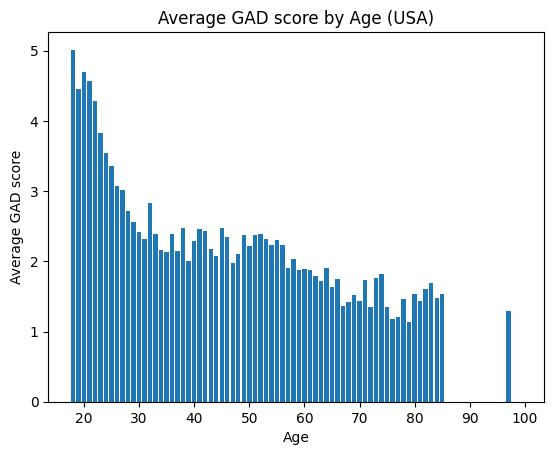

In [43]:
visualize_count_plot(usa_age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (USA)')

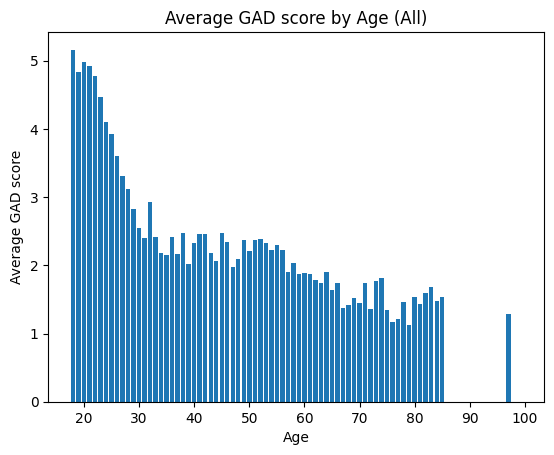

In [44]:
visualize_count_plot(age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (All)')

##### Gaming USA participant GAD scores by age

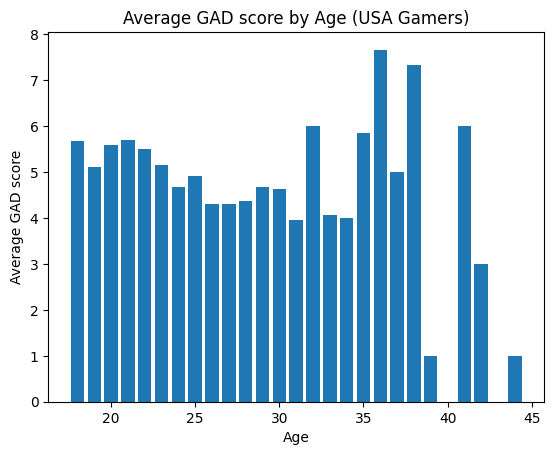

In [45]:
visualize_count_plot(gaming_age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (USA Gamers)')

##### NHIS participant GAD scores by age

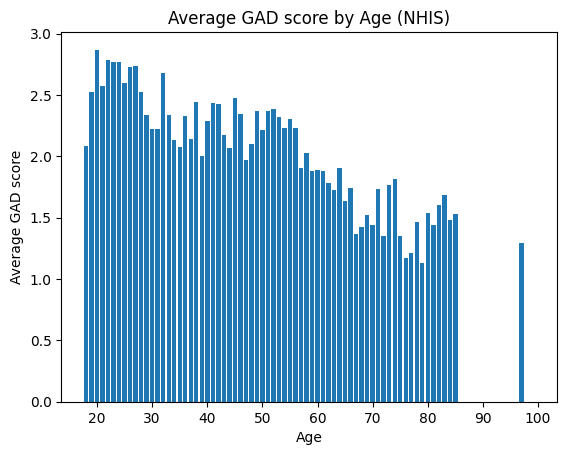

In [46]:
visualize_count_plot(nhis_age_counts, 'Age', 'Average GAD score', 'Average GAD score by Age (NHIS)')

#### How do the GAD score totals compare across reported education level?

For now, this data is displaying awkwardly because of the categories' numerical labels. In the final analysis, if I choose to investigate this further, this will be much more readable and labeled appropriately.

Update: I elected to not pursue this further for now as the concentration is on college-age adults.

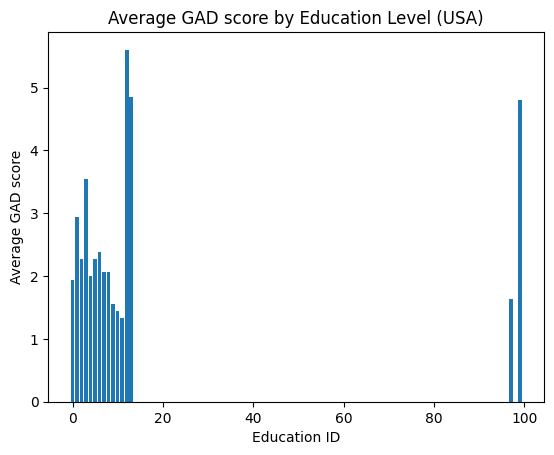

In [47]:
ax = visualize_count_plot(usa_education_counts, 'Education ID', 'Average GAD score', 'Average GAD score by Education Level (USA)')



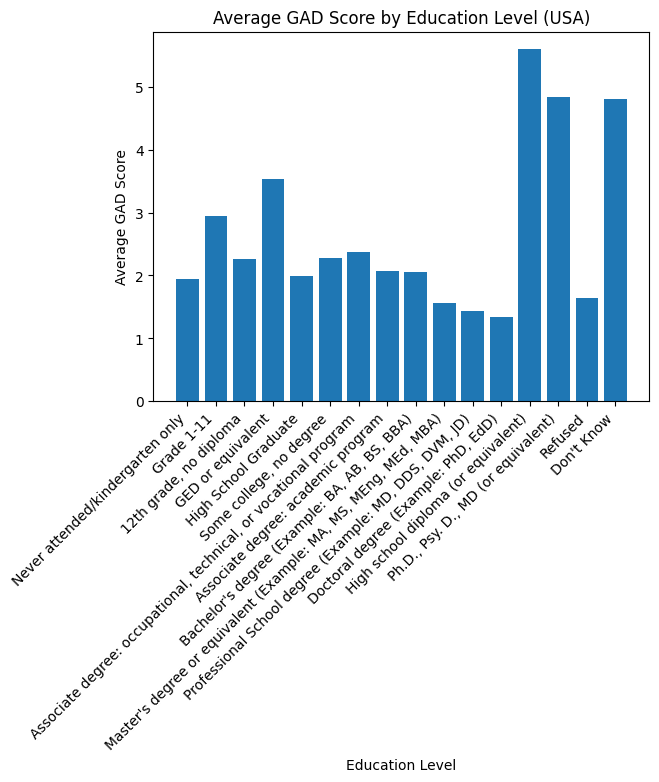

In [48]:
# plt.bar(usa_education_counts.index, usa_education_counts.values)

# plt.xlabel('Education Level')
# plt.ylabel('Average GAD Score')
# plt.title('Avg GAd by Ed Level USA')

# plt.xticks(
#     list(degree_lookup.keys()),
#     list(degree_lookup.values()), 
#     rotation=45,
#     ha='right'
#     )
# I used ChatGPT to learn that the keys/values needed 
# to be converted to a list to relabel the xaxis. Then
# to learn how to eliminate the big gap caused by the 
# range of education_id numbers below

# positions = range(len(usa_education_counts))

# plt.bar(positions, usa_education_counts.values)

# plt.xticks(
#     positions,
#     [degree_lookup[i] for i in usa_education_counts.index],
#     rotation=45,
#     ha='right'
# )

# plt.ylabel('Average GAD Score')
# plt.title('Avg GAD by Ed Level USA')

# plt.show()

visualize_and_label_count_plot(usa_education_counts, 'Education Level', 'Average GAD Score', 'Average GAD Score by Education Level (USA)', degree_lookup)


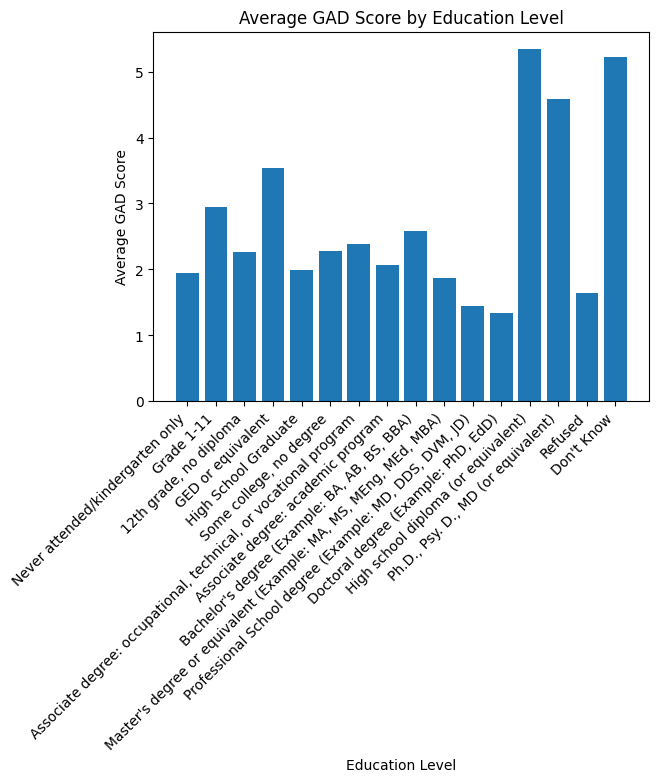

In [49]:
visualize_and_label_count_plot(education_counts, 'Education Level', 'Average GAD Score', 'Average GAD Score by Education Level', degree_lookup)

#### How do the GAD score totals compare across reported sex?
For now, this data is displaying awkwardly because of the categories' numerical labels. In the final analysis, if I choose to investigate this further, this will be much more readable and labeled appropriately.

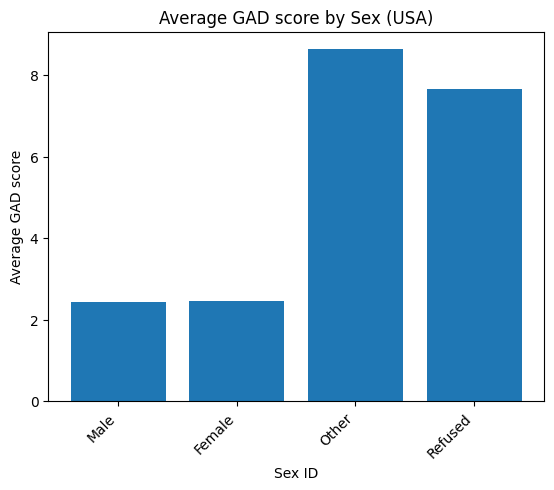

In [50]:
# visualize_count_plot(usa_sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (USA)')
visualize_and_label_count_plot(usa_sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (USA)', sex_lookup)

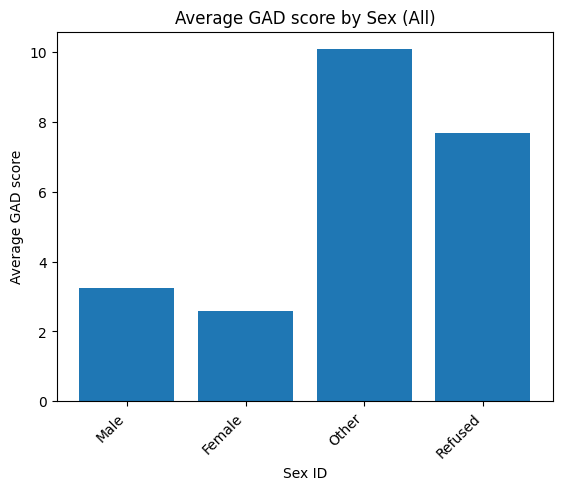

In [51]:
# visualize_count_plot(sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (All)')
visualize_and_label_count_plot(sex_counts, 'Sex ID', 'Average GAD score', 'Average GAD score by Sex (All)', sex_lookup)

#### Investigate division of ages
The gaming data is primarily younger participants. It would be a more fair analysis to compare similar age groups.

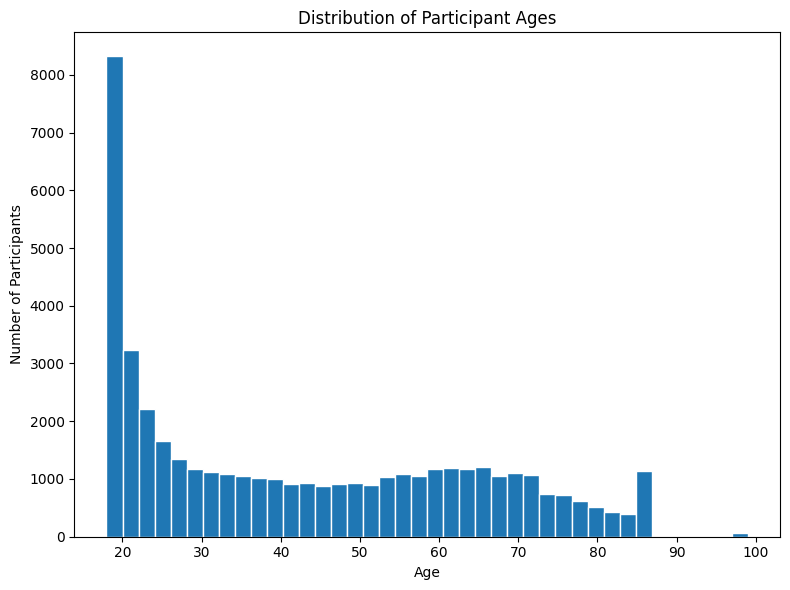

In [52]:
plt.figure(figsize=(8,6))

# Age ranges from 18-99
# Largest concentration of participants from 18-22
plt.hist(
    df['age'],
    bins=40,
    edgecolor = "white"
)

plt.xlabel('Age')
plt.ylabel('Number of Participants')
plt.title('Distribution of Participant Ages')

plt.tight_layout()
plt.show()

#### Compare NHIS and Gaming scores (ages 18-22 only)

In [53]:
gaming_usa_18_22 = gaming_usa_data[gaming_usa_data['age'].between(18,22)]
nhis_18_22 = nhis_data[nhis_data['age'].between(18,22)]

gaming_usa_18_22_scores = gaming_usa_18_22.groupby('age')['GAD_total'].mean()
nhis_18_22_scores = nhis_18_22.groupby('age')['GAD_total'].mean()


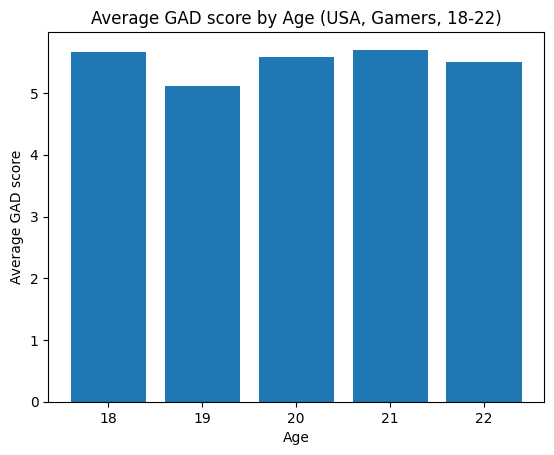

In [54]:
visualize_count_plot(gaming_usa_18_22_scores, 'Age', 'Average GAD score', 'Average GAD score by Age (USA, Gamers, 18-22)')

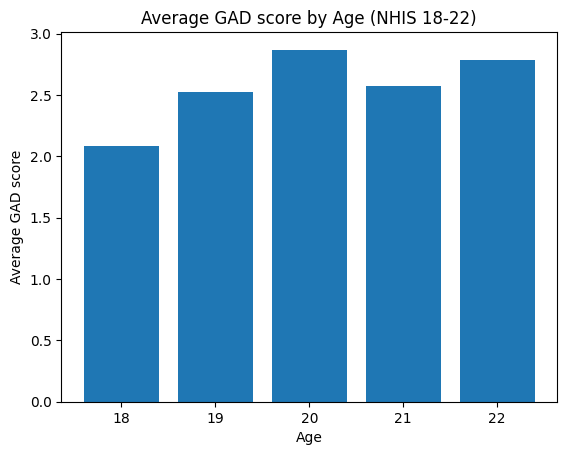

In [55]:
visualize_count_plot(nhis_18_22_scores, 'Age', 'Average GAD score', 'Average GAD score by Age (NHIS 18-22)')

### Boxplots

#### GAD scores

In [56]:
df.head()

,participant_id,OLD_participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,Degree,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
0,10000,1,2015,0,0,0,0,1,0,0,1,1,1,25,8,1,USA,Skyrim,Bachelor (or equivalent),Console,15.0,having fun,Singleplayer,Male,NaN,NaN
1,10001,2,2015,1,2,2,2,0,1,0,8,2,1,41,8,1,USA,Other,Bachelor (or equivalent),PC,8.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN
2,10002,3,2015,0,2,2,0,0,3,1,8,2,2,32,8,1,DEU,Other,Bachelor (or equivalent),PC,0.0,having fun,Singleplayer,Female,NaN,NaN
3,10003,4,2015,0,0,0,0,0,0,0,0,1,1,28,8,1,USA,Other,Bachelor (or equivalent),PC,20.0,improving,Multiplayer - online - with online acquaintanc...,Male,NaN,NaN
4,10004,5,2015,2,1,2,2,2,3,2,14,3,1,19,12,1,KOR,Other,High school diploma (or equivalent),Console,20.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


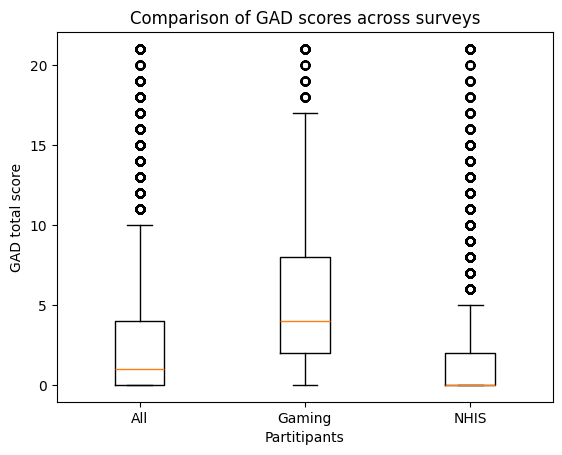

In [57]:
plt.boxplot(
    [df['GAD_total'],
    df[df['survey_id'] == 1]['GAD_total'],
    df[df['survey_id'] == 2]['GAD_total']
    ],
    tick_labels=['All', 'Gaming', 'NHIS']
)

plt.xlabel('Partitipants')
plt.ylabel('GAD total score')
plt.title('Comparison of GAD scores across surveys')

plt.show()

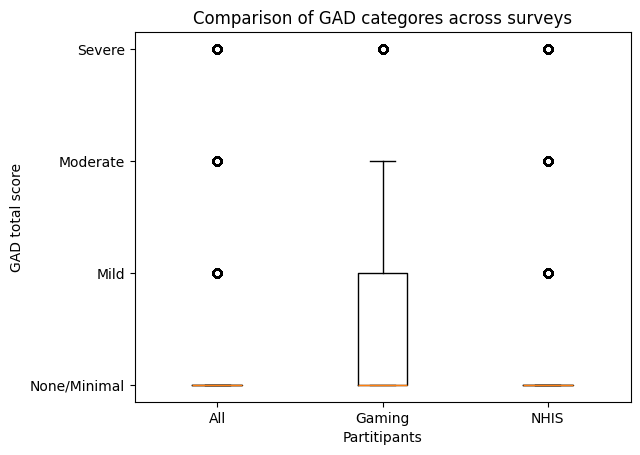

In [58]:
plt.boxplot(
    [df['GAD_cat'],
    df[df['survey_id'] == 1]['GAD_cat'],
    df[df['survey_id'] == 2]['GAD_cat']
    ],
    tick_labels=['All', 'Gaming', 'NHIS']
)

plt.yticks(ticks=[1, 2, 3, 4],
            labels=['None/Minimal', 'Mild', 'Moderate', 'Severe'])


plt.xlabel('Partitipants')
plt.ylabel('GAD total score')
plt.title('Comparison of GAD categores across surveys')

plt.show()

### Ages

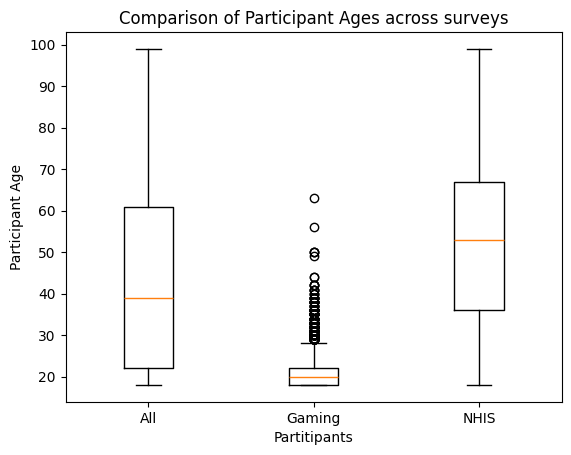

In [59]:
plt.boxplot(
    [df['age'],
    df[df['survey_id'] == 1]['age'],
    df[df['survey_id'] == 2]['age']
    ],
    tick_labels=['All', 'Gaming', 'NHIS']
)

# plt.yticks(ticks=[1, 2, 3, 4],
#             labels=['None/Minimal', 'Mild', 'Moderate', 'Severe'])


plt.xlabel('Partitipants')
plt.ylabel('Participant Age')
plt.title('Comparison of Participant Ages across surveys')

plt.show()

### Gaming Analysis
Please see preliminary_analysis/notebooks/eda for initial EDA of gaming data

## EDA observations:
- Overall, more males participated in the surveys
- Gamers exhibited a higher average GAD score, though it still ranks below the marker for mild anxiety.
- The majority of participants typically exhibited very low GAD scores across the board, regardless of gamer status.
- Younger participants tended to have higher scores, though they still ranked at or below the marker for mild anxiety.
  - In gamers, the average score dipped, then increased between about 23 and 37 years of age.
- At first glance, participants with High School diplomas or Ph.D.seemed to have higher GAD scores. Upon further reflection, the two surveys categorized these differently and there are multiple High School categories. In future explorations, I may combine all high school and GED categories together in one, but as the primary age range focus for this comparison is 18-22 year olds (typical college age), I will not use eduation as a variable to explore.
- Participants who selected 'Other' or 'Refused' for sex identification exhibited higher anxiety scores. These individuals made up <1% of participants, though, so I will not investigate further at this time.